### **👩‍🏫 👩🏿‍🏫 What You'll learn**

- Master advanced data manipulation and statistical analysis using `NumPy` and `SciPy`.
- Gain proficiency in data preprocessing and exploration with `Pandas`.
- Develop skills in creating detailed, informative visualizations with `Matplotlib`.
- Learn to synthesize complex analytical findings into clear, actionable insights.

---

### **Project Tasks**

1. Data Loading and Exploration:
    - Utilize `Pandas` to load the dataset and explore its initial structure.
    - Summarize features, target variable, and their respective data types.
    - Conduct basic descriptive statistics for an overview of the dataset.
2. Data Cleaning and Preprocessing:
    - Address missing or null values.
    - Transform categorical data into numerical format using suitable methods.
3. Statistical Analysis with `NumPy` and `SciPy`:
    - Execute detailed statistical analysis on each feature, including:
        - Calculation of central tendency measures (mean, median, mode).
        - Analysis of variability (range, variance, standard deviation).
        - Evaluation of distribution shapes through skewness and kurtosis.
    - Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).
    - Investigate feature-target correlations using `SciPy`.
    - Apply advanced `SciPy` statistical functions for deeper insights.
4. Data Visualization with `Matplotlib`:
    - Produce histograms, scatter plots, and box plots for data distribution and relationship insights.
    - Employ heatmaps for correlation visualization.
    - Ensure clarity in plots with appropriate titles, labels, and axis information.
5. Insight Synthesis and Conclusion:
    - Derive conclusions from statistical tests and visualizations.
    - Identify key determinants in mobile price classification.
    - Highlight any unexpected or significant findings.

### **📖 Useful Resources**

- Download the `train` dataset from this [repository](https://github.com/devtlv/MiniProject-DataAnalysis-W6D5-Mobile_Price_Classification/blob/main/train.csv), it comes from the [Mobile Price Classification Dataset](https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%206%20-%20Applications%20for%20Data%20Analysis/W6D5%20-%20Mini%20project/Mobile%20Price%20Classification.zip)
- Check out this page to understand the attributes | [Noise-Resilient Mobile Price Classification](https://www.kaggle.com/code/farzadnekouei/noise-resilient-mobile-price-classification)

### **Project Submission**

Submit the following in a GitHub repository:

- `Data_Analysis.ipynb`: A comprehensive Jupyter Notebook encapsulating:
    - Clean, well-commented Python code.
    - Distinct headings for each analysis phase.
    - In-depth comments elucidating findings and the importance of each analytical step.

### **Pro Tips**

- Individually examine each feature to grasp its unique traits and influence.
- Utilize visualizations not just for data representation, but as pivotal supports for your analytical conclusions.
- Reference course materials for guidance on complex statistical functions and their practical uses.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

### Data Loading and Exploration


In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [7]:
df["blue"]

0       0
1       1
2       1
3       1
4       1
       ..
1995    1
1996    1
1997    0
1998    0
1999    1
Name: blue, Length: 2000, dtype: int64

In [4]:
print(df.isnull().sum())
print(f"Duplicate rows: {df.duplicated().sum()}")

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
Duplicate rows: 0


**Dataset overview:** 2000 phones, 20 features + `price_range` (0 = low cost, 1 = medium cost, 2 = high cost, 3 = very high cost). All columns are already numeric so no encoding needed. No missing values and no duplicate rows detected.

### 2. Data Cleaning and Preprocessing

This dataset is very clean since it has no missing values and there are no categorical columns we need to encode. However, we will check whether any numeric column is a 'disguised' category that shouldn't be treated as continuous values later on (where statistical analysis wouldn't make sense, such as binary flags).


In [8]:
df.nunique().sort_values()

blue                2
dual_sim            2
four_g              2
three_g             2
touch_screen        2
wifi                2
price_range         4
n_cores             8
m_dep              10
sc_h               15
sc_w               19
talk_time          19
fc                 20
pc                 21
clock_speed        26
int_memory         63
mobile_wt         121
battery_power    1094
px_width         1109
px_height        1137
ram              1562
dtype: int64

### 3. Statistical Analysis with NumPy and SciPy

Split columns into binary flags and continuous features, since summary stats mean different things for each.


In [ ]:
continuous_cols = [
    "battery_power",
    "clock_speed",
    "fc",
    "int_memory",
    "m_dep",
    "mobile_wt",
    "n_cores",
    "pc",
    "px_height",
    "px_width",
    "ram",
    "sc_h",
    "sc_w",
    "talk_time",
]

stats_summary = pd.DataFrame(
    {
        "mean": df[continuous_cols].mean(),
        "median": df[continuous_cols].median(),
        "mode": df[continuous_cols].mode().iloc[0],
        "range": df[continuous_cols].max() - df[continuous_cols].min(),
        "variance": df[continuous_cols].var(),
        "std": df[continuous_cols].std(),
    }
)

stats_summary

,mean,median,mode,range,variance,std
battery_power,1238.51850,1226.0,618.0,1497.0,1.930884e+05,439.418206
clock_speed,1.52225,1.5,0.5,2.5,6.658629e-01,0.816004
fc,4.30950,3.0,0.0,19.0,1.884813e+01,4.341444
int_memory,32.04650,32.0,27.0,62.0,3.292670e+02,18.145715
m_dep,0.50175,0.5,0.1,0.9,8.318353e-02,0.288416
mobile_wt,140.24900,141.0,182.0,120.0,1.253136e+03,35.399655
n_cores,4.52050,4.0,4.0,7.0,5.234197e+00,2.287837
pc,9.91650,10.0,10.0,20.0,3.677592e+01,6.064315
px_height,645.10800,564.0,347.0,1960.0,1.969414e+05,443.780811
px_width,1251.51550,1247.0,874.0,1498.0,1.867964e+05,432.199447


Distribution shape check - skewness (asymmetry) and kurtosis (tailedness) for the continuous features, since `px_height`'s mean / median gap suggests skew.


In [ ]:
shape_stats = pd.DataFrame(
    {
        "skewness": stats.skew(df[continuous_cols]),
        "kurtosis": stats.kurtosis(df[continuous_cols]),
    },
    index=continuous_cols,
)

shape_stats.sort_values("skewness", ascending=False)

,skewness,kurtosis
fc,1.019046,0.273386
px_height,0.665771,-0.318075
sc_w,0.633312,-0.391548
clock_speed,0.177951,-1.323109
m_dep,0.089015,-1.274164
int_memory,0.057846,-1.216034
battery_power,0.031875,-1.224084
pc,0.017293,-1.171571
px_width,0.014776,-1.186041
talk_time,0.009505,-1.218545


`fc` (front camera MP) has the highest skewness despite a modest mean / median gap, since its scale is smaller, so a long right tail shows up strong in the standardized skewness coefficient. `px_height` has the largest 'raw' mean / median gap, but a lower skewness score due to bigger scale.

Skewness is a more reliable measure since it is scale-independent.


### Hypothesis Testing

does each feature differ across price_range groups?

Starting with `ram`: Look at its mean / standard deviation within each `price_range` group, then formally test whether those group means differ more than random noise would explain (one-way ANOVA).


In [ ]:
df.groupby("price_range")["ram"].agg(["mean", "std", "count"])

,mean,std,count
price_range,,,
0,785.314,362.755397,500
1,1679.490,465.850159,500
2,2582.816,496.211735,500
3,3449.232,393.019923,500


In [13]:
groups_ram = [
    df.loc[df["price_range"] == p, "ram"] for p in sorted(df["price_range"].unique())
]

f_stat, p_value = stats.f_oneway(*groups_ram)

print(f"F-statistic: {f_stat:.2f}, p-value: {p_value}")

F-statistic: 3520.11, p-value: 0.0


`ram` separates `price_range` groups cleanly (F = ~3500). Group means climb from ~785 to ~3450 while with-in group spread (~360 - ~500) is small by comparison, so there's almost no overlap between a group-0 (low cost) phone's RAM and a group-3 (very high cost) phone's RAM.

Now we run the same ANOVA across every continuous feature, to see which features separate price groups the most / least.


In [ ]:
anova_results = []

for col in continuous_cols:
    groups = [
        df.loc[df["price_range"] == p, col] for p in sorted(df["price_range"].unique())
    ]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append({"feature": col, "f_stat": f_stat, "p_value": p_value})

anova_df = pd.DataFrame(anova_results).sort_values("f_stat", ascending=False)

anova_df

,feature,f_stat,p_value
10,ram,3520.110824,0.000000e+00
0,battery_power,31.598158,5.948688e-20
9,px_width,22.620882,2.116911e-14
8,px_height,19.484842,1.886085e-12
5,mobile_wt,3.594318,1.311739e-02
3,int_memory,2.922996,3.277694e-02
6,n_cores,2.625415,4.893585e-02
11,sc_h,2.225984,8.324991e-02
12,sc_w,1.671000,1.712146e-01
13,talk_time,1.628811,1.806686e-01


ANOVA F-statistics rank feature strength as: `ram` dominates

---

### Feature-target correlation

Correlate every feature (continuous + binary) with `price_range`, since it is an ordinal target (0 < 1 < 2 < 3).

Pearson correlation is a reasonable choice here since it captures linear / monotonic association and applies to both binary and continuous columns.


In [ ]:
correlations = df.drop(columns="price_range").corrwith(
    (df["price_range"]).sort_values(key=abs, ascending=False)
)

correlations

battery_power    0.200723
blue             0.020573
clock_speed     -0.006606
dual_sim         0.017444
fc               0.021998
four_g           0.014772
int_memory       0.044435
m_dep            0.000853
mobile_wt       -0.030302
n_cores          0.004399
pc               0.033599
px_height        0.148858
px_width         0.165818
ram              0.917046
sc_h             0.022986
sc_w             0.038711
talk_time        0.021859
three_g          0.023611
touch_screen    -0.030411
wifi             0.018785
dtype: float64

Correlation with `price_range` confirms the ANOVA ranking: `ram` (r = 0.917) dominates, `battery_power` (r = 0.201), `px_width` (r = 0.166), and `px_height` (r = 0.149) form a distant secondary tier, and every other feature - including all six binary flags (bluetooth, dual_sim, four_g, three_g, touch_screen, wifi) - sits below |r| = 0.05. Notably, having 4G, WiFi, or a touchscreen shows almost no relationship to price tier in this dataset, which runs counter to the naive assumption that "more features = pricier phone."

---

### 4. Data Visualization

Boxplot of `ram` across `price_range` groups should visually show the clean separation we found numerically.


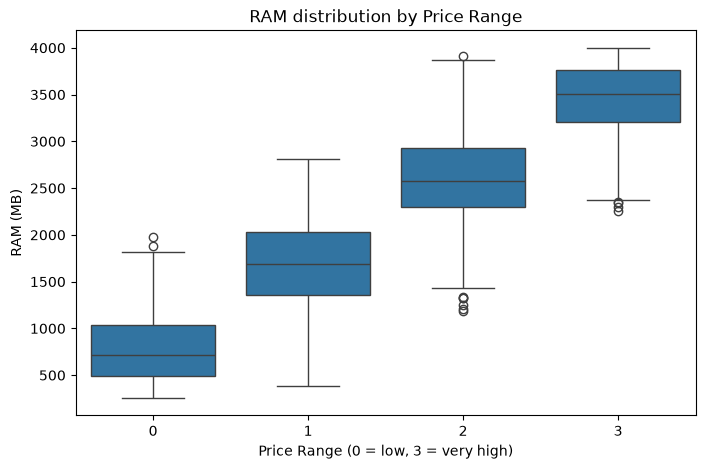

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="price_range", y="ram")
plt.title("RAM distribution by Price Range")
plt.xlabel("Price Range (0 = low, 3 = very high)")
plt.ylabel("RAM (MB)")
plt.show()

The boxplot reveals something the ANOVA F-statistic hid: while `ram` separates `price_range` groups strongly _on average_, the whiskers for adjacent groups do overlap.ANOVA tests mean separation relative to average spread, not whether every individual point is cleanly separable. So a classifier using `ram` alone would still misclassify some phones near the group boundaries, even though `ram` is by far the strongest single predictor.

---

Correlation heatmap across all features - Visual counterpart to the `corrwith` ranking above, and lets us check for correlations _between features themselves_, not just with the target.


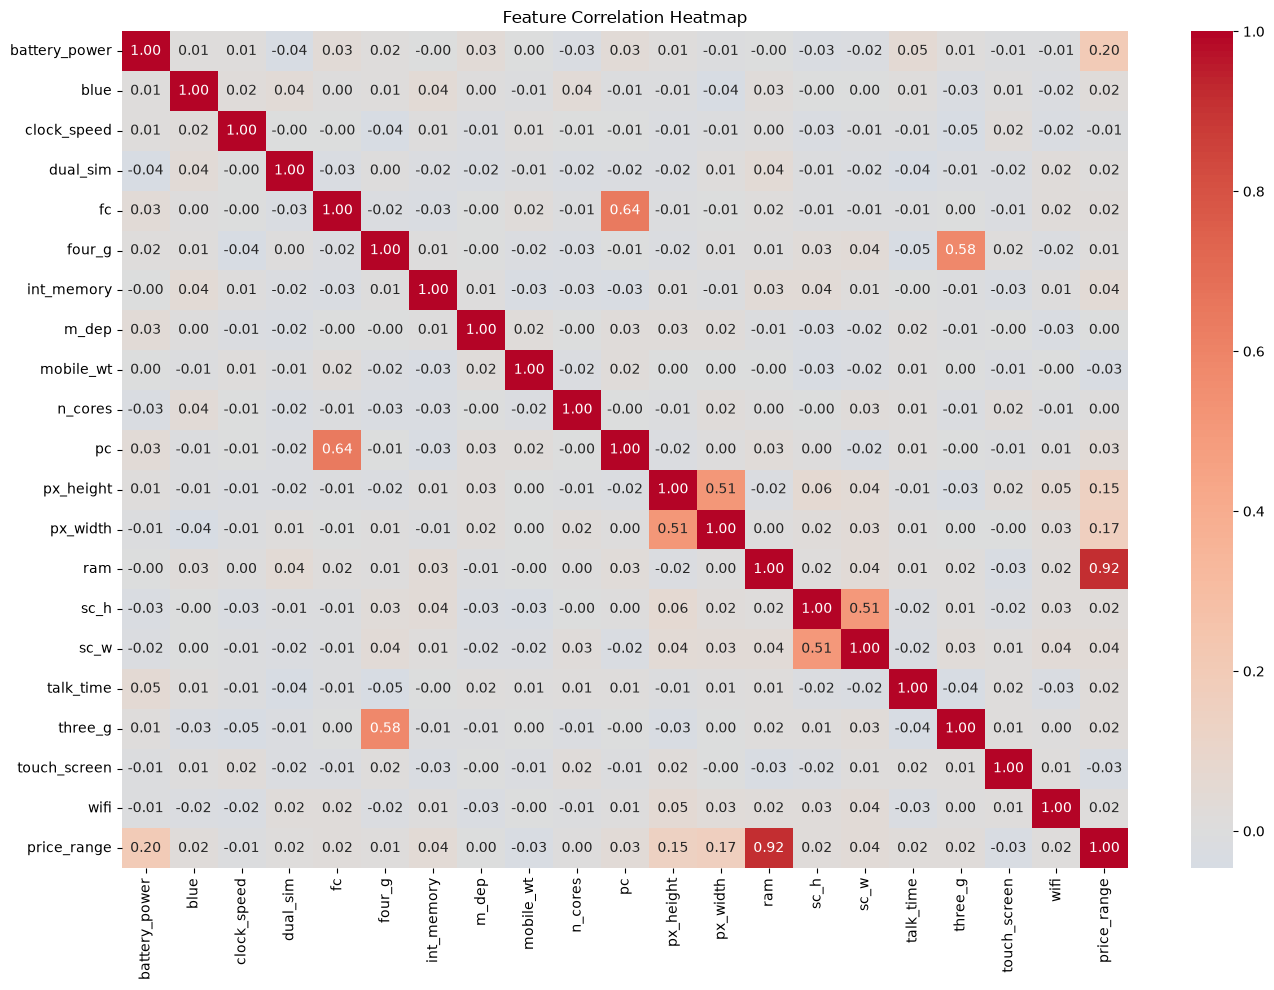

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Beyond the target correlation, three feature pairs show real correlation with each other, each explainable by real-world bundling of specs rather than coincidence:

- `fc` / `pc` (r = 0.645) - front and primary camera quality are bundled together on a given phone.
- `four_g` / `three_g` (r = 0.584) - 4G phones are backward-compatible with 3G.
- `px_height` / `px_width` (r = 0.511) - screen resolution dimensions scale together.

None of these three pairs correlate strongly with `price_range` itself, so they don't distort the price-driver ranking above, but they'd matter if this dataset fed a regression model later.

---

Histogram of `fc` - the most skewed continuous feature (skewness ~1.02) - to see the right-tail shape directly instead of just the skewness number.


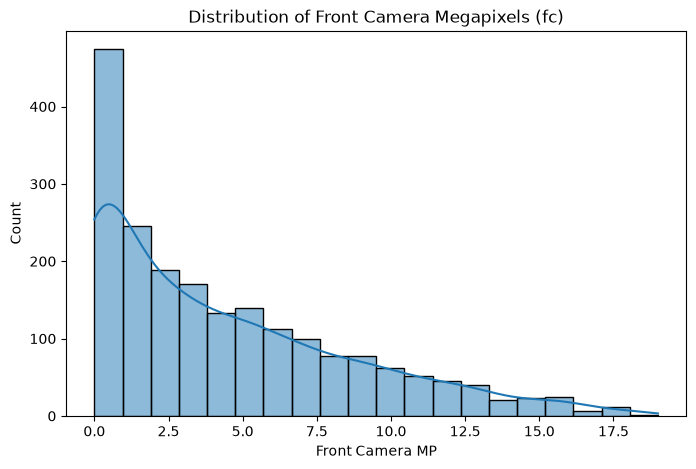

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df["fc"], bins=20, kde=True)
plt.title("Distribution of Front Camera Megapixels (fc)")
plt.xlabel("Front Camera MP")
plt.ylabel("Count")
plt.show()

`fc`'s histogram confirms its right-skew. 474 out of 2000 phones have no front camera at all (`fc = 0`), and the count thins steadily towards the max of 19 MP.


### 5. Insight Synthesis and Conclusion

**Data quality:** 2000 phones, 20 features, no missing values, no duplicates, and a perfectly balanced target (500 phones per price_range class 0-3) - no cleaning or resampling was needed.

**Key determinant of price:** `ram` overwhelmingly dominates. It has by far the largest ANOVA F-statistic (~3520 vs. the next-highest feature's ~31.6) and the strongest target correlation (r = 0.917 vs. 0.201 for the runner-up, `battery_power`). Group means climb steadily from ~785 MB (price_range 0) to ~3449 MB (price_range 3).

**But mean-level separation isn't the same as individual separability:** the `ram`-by-price*range boxplot showed real overlap between adjacent groups (e.g. group 0's range 256-1817 vs. group 1's 387-2811) - ANOVA's huge F-statistic reflects strong separation \_on average*, not that every individual phone is unambiguously classifiable by ram alone.

**Secondary drivers, a distant tier below ram:** `battery_power` (r = 0.201), `px_width` (r = 0.166), and `px_height` (r = 0.149) all show a real but far weaker relationship to price_range.

**Features with essentially no relationship to price:** all six binary flags (bluetooth, dual_sim, four_g, three_g, touch_screen, wifi) correlate under |r| = 0.03 with price_range - contrary to the intuition that "more connectivity features = higher price," this dataset shows no such pattern. `clock_speed` and `fc` similarly showed the lowest ANOVA F-statistics (both <1).

**Distribution shape:** most continuous features are close to symmetric (skewness near 0), but `fc` (front camera MP) is the most right-skewed (skewness ~1.02) - 24% of phones have no front camera at all (`fc = 0`), with a long thinning tail up to 19 MP.

**Worth noting:** `fc`/`pc` (r = 0.645), `four_g`/`three_g` (r = 0.584), and `px_height`/`px_width` (r = 0.511) are correlated with _each other_ - each explainable by real spec bundling (camera quality, network backward-compatibility, resolution dimensions scaling together) rather than a relationship to price.
